# 03 — Hypothesis Testing
**Goal:** Statistically prove which features are actually predictive of churn.

**Churn definition:** A customer is labelled as churned if their deal
closed within 4 weeks (28 days) after `Prospect_Renewal_Date` and
`Prospect_Outcome` is `Churned`.
We test 10 hypotheses. For each one:
1. State the hypothesis
2. Show the data
3. Run the statistical test
4. Conclude: is this feature worth including in the model?

**Test used:** Chi-square for categorical/binary features. Mann-Whitney U for continuous.
We use **p < 0.05** as our significance threshold.


## Setup

In [1]:
import sys, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, str(__import__('pathlib').Path.cwd().parents[1]))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from scipy import stats

from src.data.loader import load_all
from src.data.cleaner import clean_all

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 60)

PROJECT_ROOT = Path.cwd().parents[1]
FEATURES = PROJECT_ROOT / 'data' / 'features'
MODELS   = PROJECT_ROOT / 'models_saved'
REPORTS  = PROJECT_ROOT / 'reports' / 'figures'
REPORTS.mkdir(parents=True, exist_ok=True)

raw  = load_all()
data = clean_all(raw)
bills = data['billings']
cc    = data['cc_calls']
emails= data['emails']
rc    = data['renewal_calls']

print("All files loaded and cleaned.")
print(f"  billings:      {bills.shape}")
print(f"  cc_calls:      {cc.shape}")
print(f"  emails:        {emails.shape}")
print(f"  renewal_calls: {rc.shape}")

# Build labelled training dataset for hypothesis testing
from src.features.builder import build_cohort_features, build_labels

print("\nBuilding 2024 cohort for hypothesis testing...")
train_df = build_cohort_features(bills, emails, cc, rc, renewal_year=2024, include_labels=True)
print(f"Training data: {train_df.shape}")
print(f"Churn rate: {train_df['churn_label'].mean()*100:.2f}%")


All files loaded and cleaned.
  billings:      (122082, 59)
  cc_calls:      (32882, 34)
  emails:        (123389, 28)
  renewal_calls: (186534, 41)

Building 2024 cohort for hypothesis testing...
[2024] Base: 30,946 customers
[2024] Coverage — emails:29,203 cc:3,356 rc:18,595
[2024] Final: (30946, 99) ✓
[2024] Churn rate: 9.64%
Training data: (30946, 101)
Churn rate: 9.64%


## Helper Functions

In [12]:


def chi_square_test(df, feature_col, label_col='churn_label'):
    """Chi-square test for binary/categorical features."""
    ct = pd.crosstab(df[feature_col], df[label_col])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    if min(ct.shape) <= 1 or dof == 0:
        effect_size = np.nan
    else:
        effect_size = np.sqrt(chi2 / (len(df) * (min(ct.shape) - 1)))  # Cramer's V
    return {'chi2': chi2, 'p_value': p, 'cramers_v': effect_size,
            'significant': p < 0.05}


def mann_whitney_test(df, feature_col, label_col='churn_label'):
    """Mann-Whitney U test for continuous features."""
    group0 = df[df[label_col]==0][feature_col].dropna()
    group1 = df[df[label_col]==1][feature_col].dropna()
    stat, p = stats.mannwhitneyu(group0, group1, alternative='two-sided')
    # effect size r = Z / sqrt(N)
    n = len(group0) + len(group1)
    z = (stat - len(group0)*len(group1)/2) / np.sqrt(len(group0)*len(group1)*(n+1)/12)
    effect_size = abs(z) / np.sqrt(n)
    return {'statistic': stat, 'p_value': p, 'effect_size_r': effect_size,
            'significant': p < 0.05,
            'mean_retained': group0.mean(), 'mean_churned': group1.mean()}


def plot_churn_rate_comparison(df, col, title, ax, is_binary=True):
    """Plot churn rate comparison for a feature."""
    if is_binary:
        groups = df.groupby(col)['churn_label'].agg(['mean','count']).reset_index()
        groups.columns = [col, 'churn_rate', 'n']
        groups['churn_rate'] *= 100
        colors = ['#0F6E56' if v==0 else '#E63946' for v in groups[col]]
        bars = ax.bar(groups[col].astype(str), groups['churn_rate'], color=colors)
        for bar, row in zip(bars, groups.itertuples()):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                    f"{row.churn_rate:.1f}%\n(n={row.n:,})", ha='center', fontsize=9)
    else:
        groups = df.groupby(pd.qcut(df[col], q=5, duplicates='drop'))['churn_label'].mean() * 100
        groups.index = groups.index.astype(str)
        groups.plot(kind='bar', ax=ax, color='#185FA5')
        ax.tick_params(axis='x', rotation=30)
    ax.axhline(df['churn_label'].mean()*100, color='grey', ls='--', label=f'Overall mean')
    ax.set_title(title)
    ax.set_ylabel('Churn rate %')
    ax.set_ylim(0, min(40, ax.get_ylim()[1]*1.3))
    ax.legend(fontsize=8)


---
## H1 — Zero Anchor Clients → Higher Churn
**Hypothesis:** Customers with zero anchor clients (no external obligation to stay) churn significantly more than customers with 1+ anchor clients.

**Why this matters:** Anchor clients require certification — losing it would cost real business. Zero anchors = no retention lock.


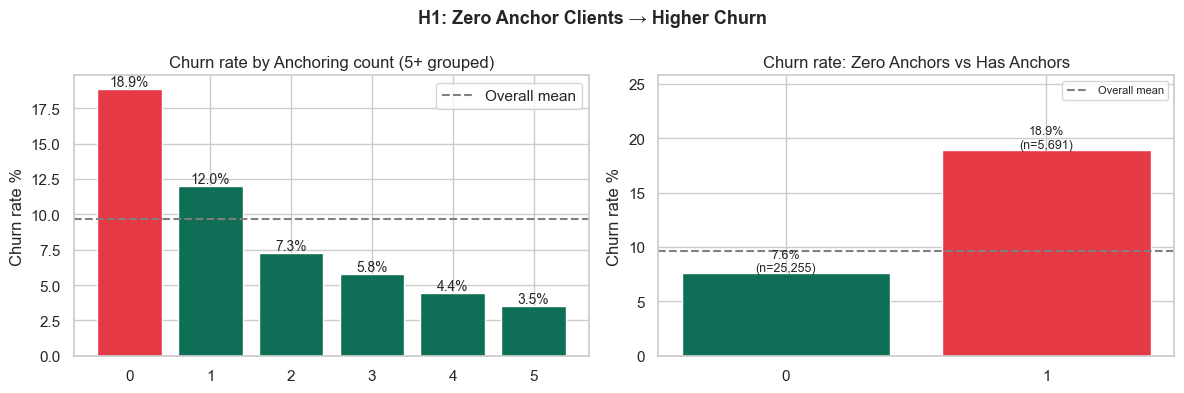

Chi-square test — anchoring_zero vs churn_label
  Chi2 = 680.45
  p-value = 0.000000
  Cramer's V = 0.1483
  Significant: True

Churn rates:
                churn_rate      n
anchoring_zero                   
0                   7.5600  25255
1                  18.8700   5691


In [13]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: churn rate at each anchoring count (capped at 5+)
train_df['anch_capped'] = train_df['Current_Anchorings'].clip(upper=5)
cr_anch = train_df.groupby('anch_capped')['churn_label'].mean() * 100
axes[0].bar(cr_anch.index.astype(str), cr_anch.values,
            color=['#E63946' if i==0 else '#0F6E56' for i in cr_anch.index])
axes[0].set_title('Churn rate by Anchoring count (5+ grouped)')
axes[0].set_ylabel('Churn rate %')
axes[0].axhline(train_df['churn_label'].mean()*100, color='grey', ls='--', label='Overall mean')
axes[0].legend()
for i, v in enumerate(cr_anch.values):
    axes[0].text(i, v+0.2, f'{v:.1f}%', ha='center', fontsize=10)

# Right: zero vs 1+
plot_churn_rate_comparison(train_df, 'anchoring_zero', 
                           'Churn rate: Zero Anchors vs Has Anchors', axes[1])
plt.suptitle('H1: Zero Anchor Clients → Higher Churn', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS / 'H1_anchorings.png', dpi=150, bbox_inches='tight')
plt.show()

result = chi_square_test(train_df, 'anchoring_zero')
print(f"Chi-square test — anchoring_zero vs churn_label")
print(f"  Chi2 = {result['chi2']:.2f}")
print(f"  p-value = {result['p_value']:.6f}")
print(f"  Cramer's V = {result['cramers_v']:.4f}")
print(f"  Significant: {result['significant']}")
print()
print("Churn rates:")
print(train_df.groupby('anchoring_zero')['churn_label'].agg(['mean','count'])
      .rename(columns={'mean':'churn_rate','count':'n'})
      .assign(churn_rate=lambda x: x['churn_rate']*100).round(2))


---
## H2 — Auto-Renewal OFF → Higher Churn
**Hypothesis:** Customers who turned off auto-renewal churn significantly more than those who kept it on.

**Why this matters:** Switching off auto-renewal is a deliberate action. It signals the customer is reconsidering.


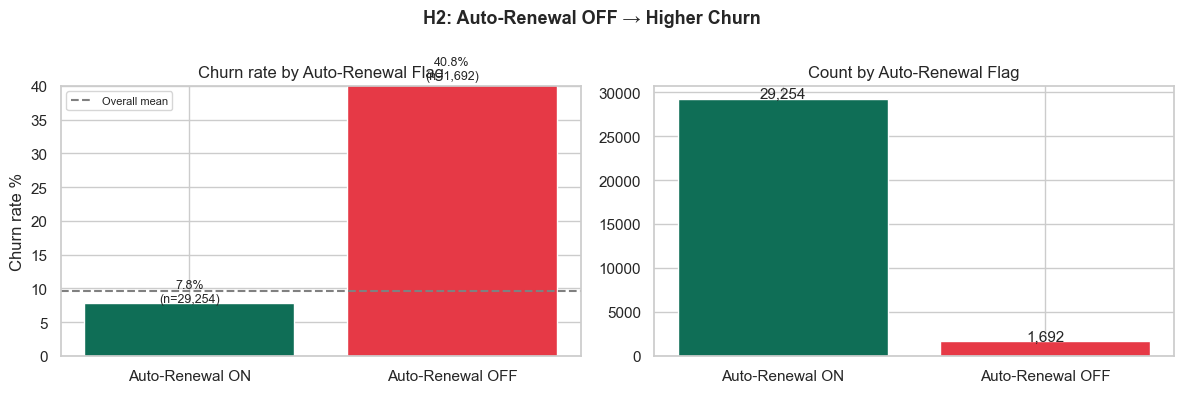

Chi-square: p=0.000000, Cramer's V=0.2539, Significant=True

auto_renewal_off
0    7.8400
1   40.8400
Name: churn_rate_%, dtype: float64


In [14]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_churn_rate_comparison(train_df, 'auto_renewal_off',
                           'Churn rate by Auto-Renewal Flag', axes[0])
axes[0].set_xticklabels(['Auto-Renewal ON', 'Auto-Renewal OFF'])

# Distribution of auto_renewal_off
counts = train_df['auto_renewal_off'].value_counts()
axes[1].bar(['Auto-Renewal ON', 'Auto-Renewal OFF'], counts.values,
            color=['#0F6E56', '#E63946'])
axes[1].set_title('Count by Auto-Renewal Flag')
for i, v in enumerate(counts.values):
    axes[1].text(i, v+50, f'{v:,}', ha='center', fontsize=11)

plt.suptitle('H2: Auto-Renewal OFF → Higher Churn', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS / 'H2_auto_renewal.png', dpi=150, bbox_inches='tight')
plt.show()

result = chi_square_test(train_df, 'auto_renewal_off')
print(f"Chi-square: p={result['p_value']:.6f}, Cramer's V={result['cramers_v']:.4f}, Significant={result['significant']}")
print()
print(train_df.groupby('auto_renewal_off')['churn_label'].mean().mul(100).round(2).rename('churn_rate_%'))


---
## H3 — Large Price Increase (>10%) → Higher Churn
**Hypothesis:** Customers who experienced a >10% price increase churn at a higher rate.


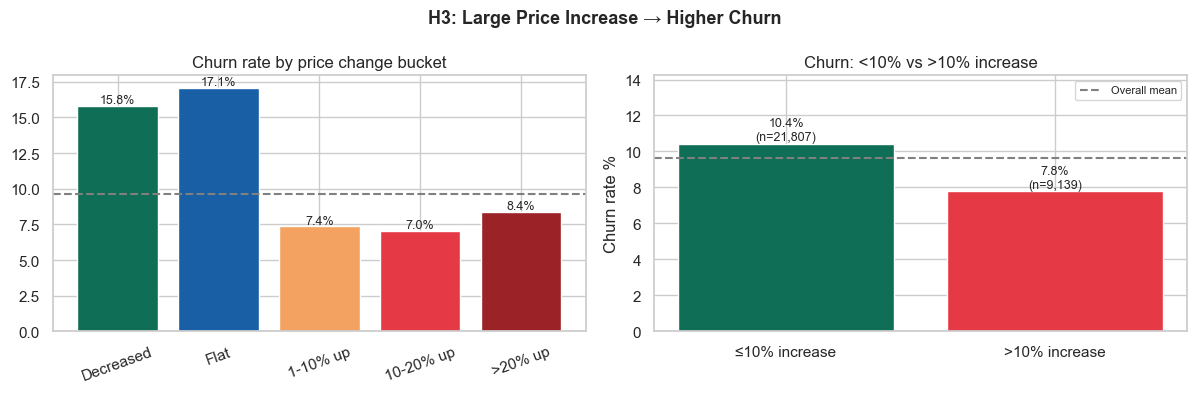

Chi-square: p=0.000000, Cramer's V=0.0407
Mann-Whitney (price_change_pct): p=0.000000, effect_r=0.0933
  Mean price change — Retained: 9.9%  Churned: 6.5%


In [15]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

train_df['price_bucket'] = pd.cut(
    train_df['price_change_pct'],
    bins=[-np.inf, -0.01, 0.01, 0.10, 0.20, np.inf],
    labels=['Decreased', 'Flat', '1-10% up', '10-20% up', '>20% up']
)
cr_price = train_df.groupby('price_bucket', observed=True)['churn_label'].mean() * 100
axes[0].bar(cr_price.index.astype(str), cr_price.values,
            color=['#0F6E56','#185FA5','#F4A261','#E63946','#9B2226'])
axes[0].set_title('Churn rate by price change bucket')
axes[0].axhline(train_df['churn_label'].mean()*100, color='grey', ls='--')
for i, v in enumerate(cr_price.values):
    axes[0].text(i, v+0.2, f'{v:.1f}%', ha='center', fontsize=9)
axes[0].tick_params(axis='x', rotation=20)

plot_churn_rate_comparison(train_df, 'price_increase_10pct',
                           'Churn: <10% vs >10% increase', axes[1])
axes[1].set_xticklabels(['≤10% increase', '>10% increase'])

plt.suptitle('H3: Large Price Increase → Higher Churn', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS / 'H3_price.png', dpi=150, bbox_inches='tight')
plt.show()

result = chi_square_test(train_df, 'price_increase_10pct')
print(f"Chi-square: p={result['p_value']:.6f}, Cramer's V={result['cramers_v']:.4f}")
result2 = mann_whitney_test(train_df, 'price_change_pct')
print(f"Mann-Whitney (price_change_pct): p={result2['p_value']:.6f}, effect_r={result2['effect_size_r']:.4f}")
print(f"  Mean price change — Retained: {result2['mean_retained']*100:.1f}%  Churned: {result2['mean_churned']*100:.1f}%")


---
## H4 — Any Leave Signal → Much Higher Churn
**Hypothesis:** When any data source (email, cc_call, renewal_call) shows a leave signal, churn rate is dramatically higher.

This is the composite feature `any_leave_signal`.


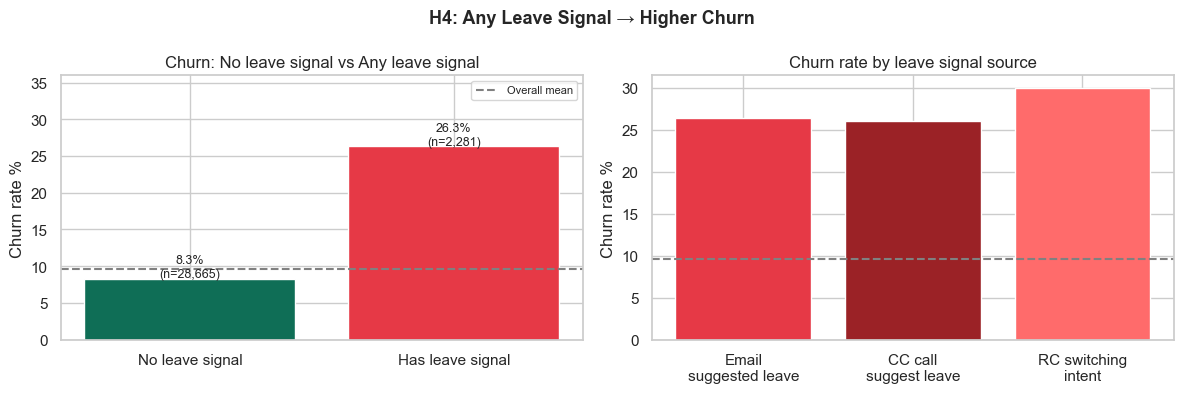

Chi-square: p=0.000000, Cramer's V=0.1594


In [16]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_churn_rate_comparison(train_df, 'any_leave_signal', 'Churn: No leave signal vs Any leave signal', axes[0])
axes[0].set_xticklabels(['No leave signal', 'Has leave signal'])

# breakdown by source
sources = ['email_ever_suggested_leave','cc_ever_suggest_leave','rc_switching_intent']
cr_sources = [train_df[train_df[s]==1]['churn_label'].mean()*100 for s in sources]
axes[1].bar(['Email\nsuggested leave','CC call\nsuggest leave','RC switching\nintent'], cr_sources,
            color=['#E63946','#9B2226','#FF6B6B'])
axes[1].set_title('Churn rate by leave signal source')
axes[1].axhline(train_df['churn_label'].mean()*100, color='grey', ls='--')
axes[1].set_ylabel('Churn rate %')

plt.suptitle('H4: Any Leave Signal → Higher Churn', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS / 'H4_leave_signal.png', dpi=150, bbox_inches='tight')
plt.show()

result = chi_square_test(train_df, 'any_leave_signal')
print(f"Chi-square: p={result['p_value']:.6f}, Cramer's V={result['cramers_v']:.4f}")


---
## H5 — Competitor Mention → Higher Churn
**Hypothesis:** Customers who mentioned a competitor in any channel churn more.


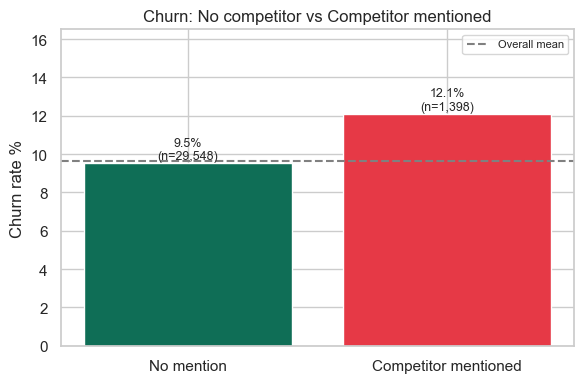

Chi-square: p=0.001781, Cramer's V=0.0178
Customers with competitor mention: 1,398 (4.5%)


In [17]:

fig, ax = plt.subplots(figsize=(6, 4))
plot_churn_rate_comparison(train_df, 'any_competitor_signal', 'Churn: No competitor vs Competitor mentioned', ax)
ax.set_xticklabels(['No mention', 'Competitor mentioned'])
plt.tight_layout()
plt.savefig(REPORTS / 'H5_competitor.png', dpi=150, bbox_inches='tight')
plt.show()

result = chi_square_test(train_df, 'any_competitor_signal')
print(f"Chi-square: p={result['p_value']:.6f}, Cramer's V={result['cramers_v']:.4f}")
n_competitor = train_df['any_competitor_signal'].sum()
print(f"Customers with competitor mention: {n_competitor:,} ({n_competitor/len(train_df)*100:.1f}%)")


---
## H6 — Short Tenure → Higher Churn
**Hypothesis:** Customers in their first 1-2 years churn more than long-tenured customers.


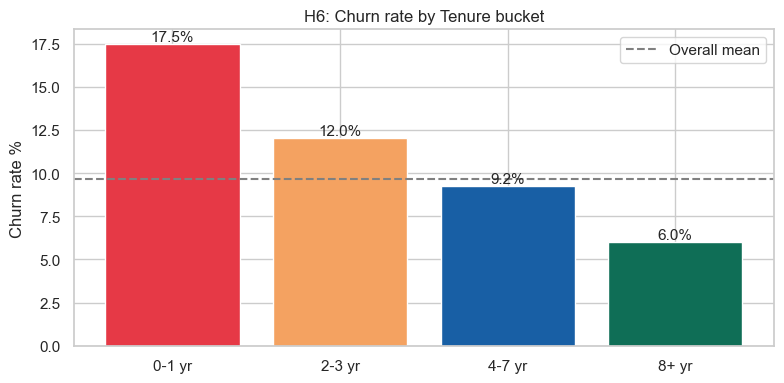

Mann-Whitney (Tenure_Years): p=0.000000
  Mean tenure — Retained: 7.3 yrs  Churned: 5.1 yrs


In [18]:

fig, ax = plt.subplots(figsize=(8, 4))
tenure_buckets = ['tenure_0_1','tenure_2_3','tenure_4_7','tenure_8plus']
labels = ['0-1 yr','2-3 yr','4-7 yr','8+ yr']
cr = [train_df[train_df[b]==1]['churn_label'].mean()*100 for b in tenure_buckets]
bars = ax.bar(labels, cr, color=['#E63946','#F4A261','#185FA5','#0F6E56'])
ax.axhline(train_df['churn_label'].mean()*100, color='grey', ls='--', label='Overall mean')
for bar, v in zip(bars, cr):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.2, f'{v:.1f}%', ha='center', fontsize=11)
ax.set_title('H6: Churn rate by Tenure bucket')
ax.set_ylabel('Churn rate %')
ax.legend()
plt.tight_layout()
plt.savefig(REPORTS / 'H6_tenure.png', dpi=150, bbox_inches='tight')
plt.show()

result = mann_whitney_test(train_df, 'Tenure_Years')
print(f"Mann-Whitney (Tenure_Years): p={result['p_value']:.6f}")
print(f"  Mean tenure — Retained: {result['mean_retained']:.1f} yrs  Churned: {result['mean_churned']:.1f} yrs")


---
## H7 — Payment Method UNKNOWN → Higher Churn


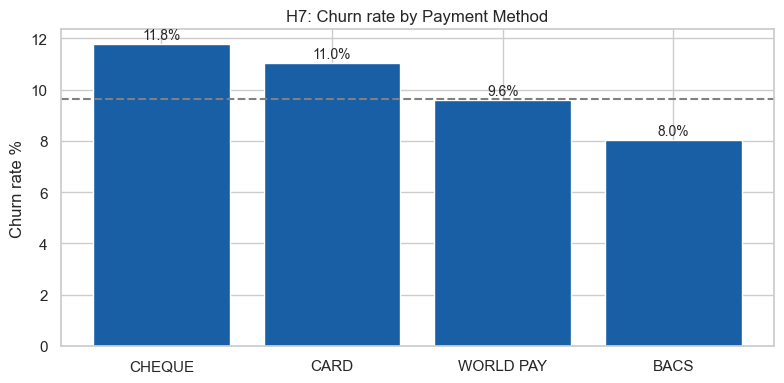

Chi-square: p=1.000000, Cramer's V=nan


In [19]:

fig, ax = plt.subplots(figsize=(8, 4))
cr_pay = train_df.groupby('Payment_Method')['churn_label'].mean().sort_values(ascending=False) * 100
colors = ['#E63946' if p=='UNKNOWN' else '#185FA5' for p in cr_pay.index]
bars = ax.bar(cr_pay.index, cr_pay.values, color=colors)
ax.axhline(train_df['churn_label'].mean()*100, color='grey', ls='--')
ax.set_title('H7: Churn rate by Payment Method')
ax.set_ylabel('Churn rate %')
for bar, v in zip(bars, cr_pay.values):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.2, f'{v:.1f}%', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig(REPORTS / 'H7_payment.png', dpi=150, bbox_inches='tight')
plt.show()

result = chi_square_test(train_df, 'payment_unknown')
print(f"Chi-square: p={result['p_value']:.6f}, Cramer's V={result['cramers_v']:.4f}")


---
## H8 — Negative Email Sentiment → Higher Churn

**⚠ SKIPPED:** Email features are excluded from the post-renewal pipeline.
`emails.year = Renewal_Year + 1` means email data arrives AFTER the renewal decision.
Using it would be temporal leakage.


Mann-Whitney (email_pct_negative): p=0.000000, effect=0.0319
  Mean % negative — Retained: 5.6%  Churned: 12.0%


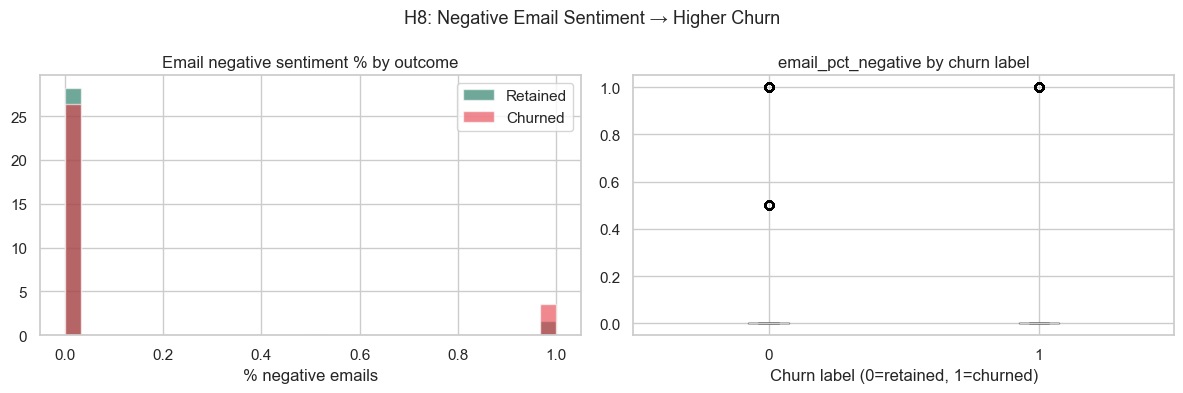

In [20]:
# H8 — SKIPPED: Email features excluded (temporal leakage for post-renewal use case)
print("H8 — Negative Email Sentiment: SKIPPED")
print("Reason: emails.year = Renewal_Year + 1 — data arrives after renewal decision.")


---
## H9 — More Negative Flags = Higher Churn (Dose-Response)
If the model features are real, churn rate should rise monotonically with total_negative_flags.
This is the dose-response check.


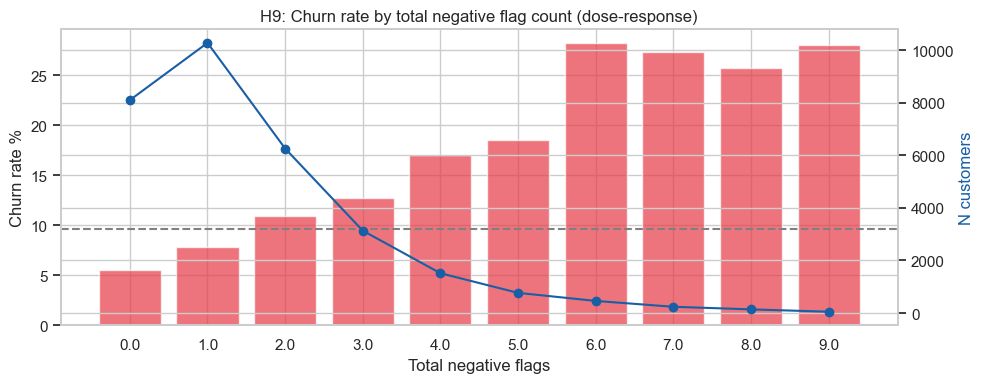

Mann-Whitney: p=0.000000
  Mean flags — Retained: 1.48  Churned: 2.28


In [21]:

fig, ax = plt.subplots(figsize=(10, 4))
flag_cr = train_df.groupby('total_negative_flags')['churn_label'].agg(['mean','count'])
flag_cr = flag_cr[flag_cr['count'] >= 20]  # only groups with enough samples
flag_cr['churn_rate'] = flag_cr['mean'] * 100

ax.bar(flag_cr.index.astype(str), flag_cr['churn_rate'], color='#E63946', alpha=0.7)
ax2 = ax.twinx()
ax2.plot(range(len(flag_cr)), flag_cr['count'].values, 'o-', color='#185FA5', label='N customers')
ax2.set_ylabel('N customers', color='#185FA5')
ax.set_title('H9: Churn rate by total negative flag count (dose-response)')
ax.set_xlabel('Total negative flags')
ax.set_ylabel('Churn rate %')
ax.axhline(train_df['churn_label'].mean()*100, color='grey', ls='--')
plt.tight_layout()
plt.savefig(REPORTS / 'H9_dose_response.png', dpi=150, bbox_inches='tight')
plt.show()

result = mann_whitney_test(train_df, 'total_negative_flags')
print(f"Mann-Whitney: p={result['p_value']:.6f}")
print(f"  Mean flags — Retained: {result['mean_retained']:.2f}  Churned: {result['mean_churned']:.2f}")


---
## H10 — Hypothesis Summary Table


In [22]:

hypotheses = [
    ('H1', 'anchoring_zero',           'Chi-square', 'binary'),
    ('H2', 'auto_renewal_off',         'Chi-square', 'binary'),
    ('H3', 'price_increase_10pct',     'Chi-square', 'binary'),
    ('H4', 'any_leave_signal',         'Chi-square', 'binary'),
    ('H5', 'any_competitor_signal',    'Chi-square', 'binary'),
    ('H7', 'payment_unknown',          'Chi-square', 'binary'),
    ('H6', 'Tenure_Years',             'Mann-Whitney','continuous'),
    ('H8', 'email_pct_negative',       'Mann-Whitney','continuous'),
    ('H9', 'total_negative_flags',     'Mann-Whitney','continuous'),
]

rows = []
for hyp_id, feature, test_type, ftype in hypotheses:
    if feature not in train_df.columns:
        continue
    if ftype == 'binary':
        r = chi_square_test(train_df, feature)
        cr_0 = train_df[train_df[feature]==0]['churn_label'].mean()*100
        cr_1 = train_df[train_df[feature]==1]['churn_label'].mean()*100
        rows.append({
            'Hypothesis': hyp_id,
            'Feature': feature,
            'Test': test_type,
            'p-value': round(r['p_value'], 6),
            'Effect Size': round(r['cramers_v'], 4),
            'Churn if 0': round(cr_0,1),
            'Churn if 1': round(cr_1,1),
            'Lift (1 vs 0)': round(cr_1/cr_0, 2) if cr_0 > 0 else 'N/A',
            'Significant': '✓' if r['significant'] else '✗',
        })
    else:
        r = mann_whitney_test(train_df, feature)
        rows.append({
            'Hypothesis': hyp_id,
            'Feature': feature,
            'Test': test_type,
            'p-value': round(r['p_value'], 6),
            'Effect Size': round(r['effect_size_r'], 4),
            'Mean Retained': round(r['mean_retained'],3),
            'Mean Churned': round(r['mean_churned'],3),
            'Significant': '✓' if r['significant'] else '✗',
        })

summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False))
summary_df.to_csv(PROJECT_ROOT / 'reports' / 'hypothesis_results.csv', index=False)
print("\nSaved → reports/hypothesis_results.csv")


Hypothesis               Feature         Test  p-value  Effect Size  Churn if 0  Churn if 1  Lift (1 vs 0) Significant  Mean Retained  Mean Churned
        H1        anchoring_zero   Chi-square   0.0000       0.1483      7.6000     18.9000         2.5000           ✓            NaN           NaN
        H2      auto_renewal_off   Chi-square   0.0000       0.2539      7.8000     40.8000         5.2100           ✓            NaN           NaN
        H3  price_increase_10pct   Chi-square   0.0000       0.0407     10.4000      7.8000         0.7500           ✓            NaN           NaN
        H4      any_leave_signal   Chi-square   0.0000       0.1594      8.3000     26.3000         3.1700           ✓            NaN           NaN
        H5 any_competitor_signal   Chi-square   0.0018       0.0178      9.5000     12.1000         1.2700           ✓            NaN           NaN
        H7       payment_unknown   Chi-square   1.0000          NaN      9.6000         NaN            NaN      